# 03 - Feature Engineering

## Purpose and Scope

This notebook encompasses incredibly critical **Feature Engineering** transformations directly architected for the thesis's artificial intelligence models (Random Forest, XGBoost, LightGBM, CNN, LSTM). Recognizing the harsh predictive limitations of strictly raw inputs, the data is algorithmically dissected to convert hidden mathematical and chronological interactions into highly accessible machine learning signals. The ultimate predictive prowess of the models forecasting job runtimes heavily relies upon the superior quality of this feature matrix architecture.

The core computational transformations engineered in this notebook and their corresponding contributions to the thesis are:

1. **Sweep-Line Ambient Load Derivation:** In rigid adherence to queueing theory principles dictating that "system occupancy severely impacts actual job execution durations," sophisticated Sweep-Line methodologies are deployed to dynamically reconstruct point-in-time snapshot metrics of cluster CPU/GPU contention precisely at each job's arrival.
2. **Diurnal and Chronological Signals (Temporal Features):** Extracting an hour-of-day phase and a trace-relative day index (0, 1, 2, ...) from raw `arrival_time` logs to allow complex networks (particularly deep sequential models) to recognize rhythm-based batch submission behaviors as an explicit structural pattern. Neither signal is calendar-anchored: the public trace release does not disclose its collection date, so `day_of_week` counts days from the first arrival and is *not* a weekday.
3. **High Cardinality Categorical Resolution (Encoding):** Statistically mapping highly cardinal dimensions like `user` identity and `gpu_type` hardware into model feature spaces via strictly enforced One-Hot encoding (and Native Categorical formats for LightGBM) to aggressively incorporate subjective developer behavior profiles into the predictive outcome.
4. **Strict Chronological Train/Test Segregation:** Expressly rejecting conventional randomized data splitting, which fatally induces chronological data-leakage in production clusters. Instead, segregating the data rigidly along a hard timeline (80/20 split) to explicitly test generalization capabilities and validate how models fare against strictly *future* workload behaviors.

The resultant significantly enriched feature matrices (divided robustly into train and test sets) form the absolute baseline tensors dispatched directly into Notebook 04 (Model Training) for massive-scale parallel computing evaluation.


In [1]:
# ── 0. Environment & Path Setup ──────────────────────────────────────────────
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Anchor on a marker that only exists at the repository root, so the notebook
# works regardless of the directory the kernel was started from. parents[1]
# resolved one level short when the working directory was notebooks/.
def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    return start.parents[1]

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"[Setup] Project root : {PROJECT_ROOT}")
print(f"[Setup] Python path  : {sys.executable}")

[Setup] Project root : /Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling
[Setup] Python path  : /Users/hasanugurcelebi/Thesis/alibaba-gpu-runtime-prediction-and-scheduling/venv/bin/python


> **Environment and Root Path:** The project root directory is dynamically resolved and injected into `sys.path` to preserve absolute pathing between modules.

In [2]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loading import load_sample
from src.feature_engineering import (
    build_job_table_from_sample,
    add_temporal_features,
    add_categorical_features,
    add_cluster_utilization_features,
    build_feature_matrix,
)

# Unified visualisation theme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.family": "DejaVu Sans",
    # ── Publication-grade output ───────────────────────────────────────────
    # scripts/export_thesis_results.py scrapes the notebook's own inline PNG,
    # so the inline dpi is what reaches the thesis. At the 100 dpi default
    # these exported at 147-280 ppi, under the 300 ppi publisher floor.
    "figure.dpi": 200,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    # Figures are authored on a generous canvas, 10 to 18 in, and printed into
    # a 6.10-in column, roughly a 0.35 to 0.55x reduction. Shrinking the canvas
    # to match the print width made every panel cramped, so the canvas stays
    # and the type is scaled instead: at 15 pt a 14-in figure prints at 6.5 pt,
    # above the ~6 pt legibility floor.
    "font.size": 15,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 19,
})

print("[Setup] All imports OK.")


[Setup] All imports OK.


> **Library Imports:** All foundational Python and scientific libraries required for data processing, visualization, and system operations have been successfully imported.

In [3]:
# ── 2. Load raw data ──────────────────────────────────────────────────────────
print("[Step 1] Loading raw dataset...")
raw_df = load_sample(which="main")

print(f"[Step 1] Shape : {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
raw_df.head()

[Step 1] Loading raw dataset...
[Step 1] Shape : 100,000 rows × 8 columns


,job_id,num_inst,submit_time,num_cpu,num_gpu,gpu_type,duration,user
0,0,1.0,0,2.0,0.00,CPU,1268,d4d51aca8806
1,1,12.0,3,6.0,0.25,T4,15748,d4d51aca8806
2,2,1.0,5,6.0,1.00,MISC,84,a8192d6b0ae9
3,3,1.0,21,18.0,1.00,T4,46,c7152ce0fec1
4,4,1.0,21,6.0,1.00,MISC,80,7b76597f4283


> **Raw Data Loading:** The 100,000-row raw GPU dispatch log has been ingested from disk. This dataset forms the foundational pool upon which all models will be trained.

In [4]:
# ── 3. Schema inspection ──────────────────────────────────────────────────────
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   job_id       100000 non-null  int64  
 1   num_inst     100000 non-null  float64
 2   submit_time  100000 non-null  int64  
 3   num_cpu      100000 non-null  float64
 4   num_gpu      100000 non-null  float64
 5   gpu_type     100000 non-null  object 
 6   duration     100000 non-null  int64  
 7   user         100000 non-null  object 
dtypes: float64(3), int64(3), object(2)
memory usage: 6.1+ MB


> **Schema Inspection:** The memory footprint (6.1+ MB) and data types of the 8 foundational attributes (e.g., `job_id`, `gpu_type`) of the raw data have been validated.

In [5]:
# ── 4. Normalise raw data ─────────────────────────────────────────────────────
print("[Step 2] Building canonical job table...")
# include_cpu_only=True mirrors prepare_features_for_model(), which is what
# notebooks 04 and 05 train and simulate on. The sweep-line below has to see
# every job holding resources, CPU-only jobs included, or the background-load
# features this chapter illustrates are not the ones the models are given. GPU
# jobs are selected after the sweep-line, not before.
job_df = build_job_table_from_sample(raw_df, time_unit="s", include_cpu_only=True)

print(f"[Step 2] Jobs incl. CPU-only : {len(job_df):,}  (removed {len(raw_df)-len(job_df):,} invalid rows)")
job_df.head()

[Step 2] Building canonical job table...
[Step 2] Jobs incl. CPU-only : 100,000  (removed 0 invalid rows)


,job_id,arrival_time,arrival_sec,job_runtime,gpu_demand,user,gpu_type,num_inst,num_cpu
0,0,1970-01-01 00:00:00,0.0,1268.0,0.00,d4d51aca8806,CPU,1.0,2.0
1,1,1970-01-01 00:00:03,3.0,15748.0,0.25,d4d51aca8806,T4,12.0,6.0
2,2,1970-01-01 00:00:05,5.0,84.0,1.00,a8192d6b0ae9,MISC,1.0,6.0
3,3,1970-01-01 00:00:21,21.0,46.0,1.00,c7152ce0fec1,T4,1.0,18.0
4,4,1970-01-01 00:00:21,21.0,80.0,1.00,7b76597f4283,MISC,1.0,6.0


> **Data Normalization:** Unix timestamps and categorical formats in the raw data have been parsed and converted into standard pandas data types to ensure accurate downstream analysis.

In [6]:
# ── 5. Shape check ────────────────────────────────────────────────────────────
print(f"[Step 2] Feature matrix shape : {job_df.shape}")

[Step 2] Feature matrix shape : (100000, 9)


> **Data Filtering and Shape Check:** The table still holds all 100,000 records at this point, `include_cpu_only=True` deliberately keeps the 17,816 CPU-only jobs (`num_gpu == 0`) so that the sweep-line below measures the load a job actually arrives into. The raw trace has no missing or non-positive durations, so nothing is removed here; the restriction to the 82,184 modelled GPU jobs happens after the sweep-line, in the cell below.


In [7]:
# ── 6. Cluster utilisation features ──────────────────────────────────────────
print("[Step 3] Computing cluster utilisation features (sweep-line)...")
job_df = add_cluster_utilization_features(job_df)

# The sweep-line has now seen the CPU-only jobs; restrict to GPU jobs, which
# are what the thesis models. Same order as prepare_features_for_model().
_n_all = len(job_df)
job_df = job_df[job_df["gpu_demand"] > 0].copy().reset_index(drop=True)
print(f"[Step 3] Restricted to GPU jobs : {len(job_df):,} of {_n_all:,}")

print(f"[Step 3] New columns : cluster_load_cpu, cluster_load_gpu, active_job_count")
job_df[["arrival_sec", "gpu_demand", "cluster_load_gpu",
        "active_job_count"]].head()

[Step 3] Computing cluster utilisation features (sweep-line)...
[Step 3] Restricted to GPU jobs : 82,184 of 100,000
[Step 3] New columns : cluster_load_cpu, cluster_load_gpu, active_job_count


,arrival_sec,gpu_demand,cluster_load_gpu,active_job_count
0,3.0,0.25,0.00,1
1,5.0,1.00,0.25,2
2,21.0,1.00,2.25,4
3,21.0,1.00,2.25,4
4,36.0,1.00,3.25,5


> **Sweep-Line Event Scanning (Cluster Utilization Derivation):**
> To aggressively sensitize the predictive models to ambient hardware contention, the exact cluster occupancy at the moment of each job's arrival was retroactively calculated. 
>
> Since deriving thousands of overlapping job executions via naive O(N²) looping is computationally prohibitive, all submit and completion logs were mapped chronologically and processed using a high-efficiency **Event-Driven Sweep-Line Algorithm**. This gracefully embedded the **instantaneous active CPU/GPU load and concurrent background job count** at the precise second of arrival into the feature matrix, fundamentally avoiding temporal data leakage.


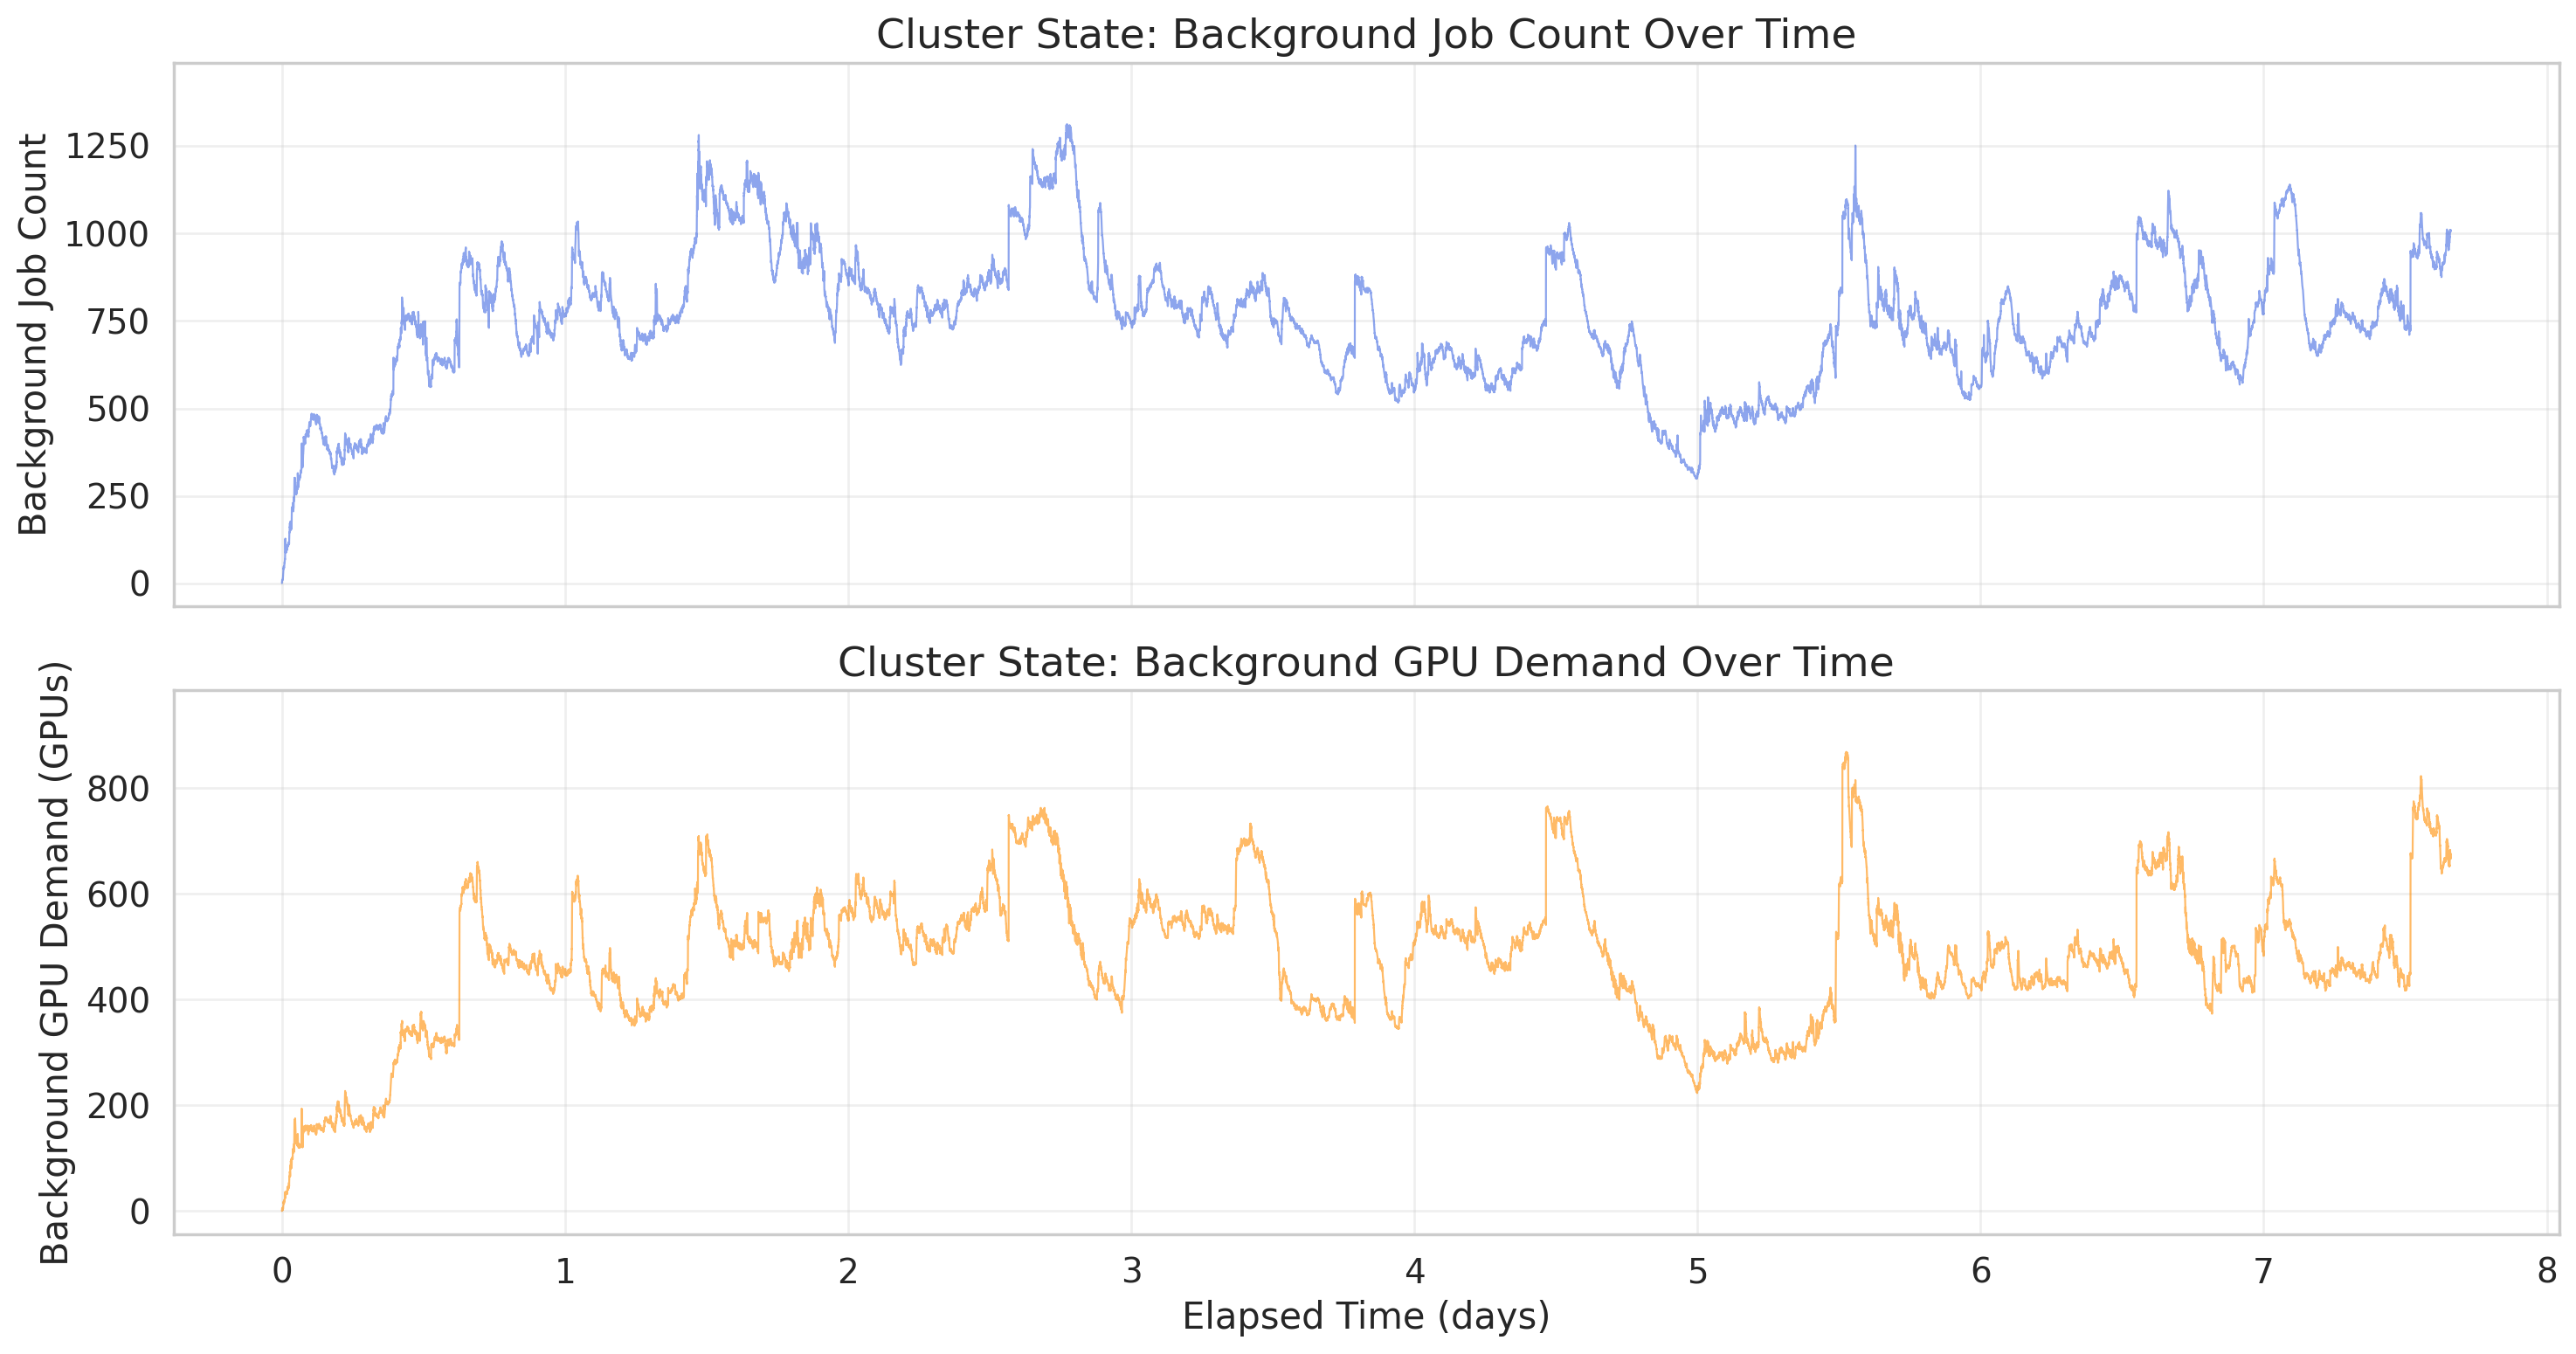

In [8]:
# ── 7. Active job count over time ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(job_df["arrival_sec"] / 86400, job_df["active_job_count"],
             alpha=0.6, lw=0.8, color="royalblue", label="Active Jobs")
axes[0].set_ylabel("Background Job Count")
axes[0].set_title("Cluster State: Background Job Count Over Time")
# One series per panel, so a one-entry legend only repeated the title, and in
# the lower panel it sat on top of a late-trace peak. Dropped both.
axes[0].grid(True, alpha=0.3)

axes[1].plot(job_df["arrival_sec"] / 86400, job_df["cluster_load_gpu"],
             alpha=0.6, lw=0.8, color="darkorange", label="GPU Demand")
axes[1].set_ylabel("Background GPU Demand (GPUs)")
axes[1].set_xlabel("Elapsed Time (days)")
axes[1].set_title("Cluster State: Background GPU Demand Over Time")
axes[1].grid(True, alpha=0.3)
# Headroom so the peaks are not flush against the frame.
for _ax in axes:
    _lo, _hi = _ax.get_ylim()
    _ax.set_ylim(_lo, _hi * 1.08)

plt.tight_layout()
plt.show()

> **Figure 1 — 8-Day Traces of Active Jobs and Cumulative GPU Demand:**
>
> The plotted time-series explicitly materializes the dynamics of the engineered Sweep-line features across an **~8-day anonymized trace window**. The upper visualization demonstrates how the ambient **Active Job Count** violently erupts from a baseline of ~400, breaching the 1,000 mark through volatile, sudden **bursts**. The corresponding **Cumulative GPU Demand** (lower plot) intensely shadows these fluctuations, peaking critically near an 800 simultaneous GPU utilization.
>
> This extreme volatility visually certifies why static scheduling mechanisms inevitably collapse, completely mandating the artificial intelligence engines to ingest these point-in-time background contention spikes natively as predictive features.


In [9]:
# ── 8. Temporal features ──────────────────────────────────────────────────────
# IMPORTANT: add_temporal_features needs arrival_time — call BEFORE any drop.
print("[Step 5] Extracting temporal features from arrival_time...")
job_df = add_temporal_features(job_df)

print("[Step 5] New columns : hour_of_day, day_of_week")
job_df[["arrival_time", "hour_of_day", "day_of_week"]].head()

[Step 5] Extracting temporal features from arrival_time...
[Step 5] New columns : hour_of_day, day_of_week


,arrival_time,hour_of_day,day_of_week
0,1970-01-01 00:00:03,0,0
1,1970-01-01 00:00:05,0,0
2,1970-01-01 00:00:21,0,0
3,1970-01-01 00:00:21,0,0
4,1970-01-01 00:00:36,0,0


> **Chronological Signals (Temporal Features):**
> Recognizing that job submissions on the cluster follow a rhythmic pacing rather than pure randomness, the intrinsic `hour_of_day` and `day_of_week` parameters have been derived from `arrival_time`.
>
> Both are trace-relative, not calendar-anchored. `hour_of_day` is a 24-hour phase of unknown absolute alignment: the trace's `submit_time` is an offset from the start of the trace and the public release does not disclose the real collection date, so "hour 9" is not 9am in any verifiable sense. `day_of_week` is, despite its name, an absolute day counter from the first arrival (0, 1, 2, ...), over this ~7.7-day trace it takes eight distinct values (0-7), which a calendar weekday could not, so it carries no weekday/weekend meaning and must not be read as e.g. "Monday" (see the day-index correction in Notebook 01). A true `dt.dayofweek` was rejected precisely because it would fold trace-day 0 and trace-day 7 onto the same label across the chronological train/test split.
>
> What survives is the *relative* rhythm, which hours of a day are busier than the rest, and how load drifts from one trace day to the next, and that is what deep sequential architectures (like the LSTM) can exploit. The generated cyclic features are specifically encoded in the highly efficient `int32` memory format to completely eliminate memory overflow overhead.

In [10]:
# ── 9. Categorical encoding ───────────────────────────────────────────────────
print("[Step 6] Encoding categorical features...")
job_df = add_categorical_features(job_df)

# arrival_time is no longer needed after temporal extraction
job_df = job_df.drop(columns=["arrival_time"], errors="ignore")

print("[Step 6] Column dtypes:")
print(job_df.dtypes.to_string())

[Step 6] Encoding categorical features...
[Step 6] Column dtypes:
job_id                 int64
arrival_sec          float64
job_runtime          float64
gpu_demand           float64
user                category
gpu_type            category
num_inst             float64
num_cpu              float64
cluster_load_cpu     float64
cluster_load_gpu     float64
active_job_count       int64
hour_of_day            int32
day_of_week            int64


> **Categorical Encoding:** To fully exploit the native categorical processing capabilities of advanced tree-based models (LightGBM, XGBoost), the high-cardinality `user` and `gpu_type` identities have been explicitly cast to the `category` datatype. 
> 
> This strategic optimization completely bypasses the massive memory footprint (curse of dimensionality) universally associated with One-Hot arrays, dramatically accelerating the training pipeline with minimized memory overhead.

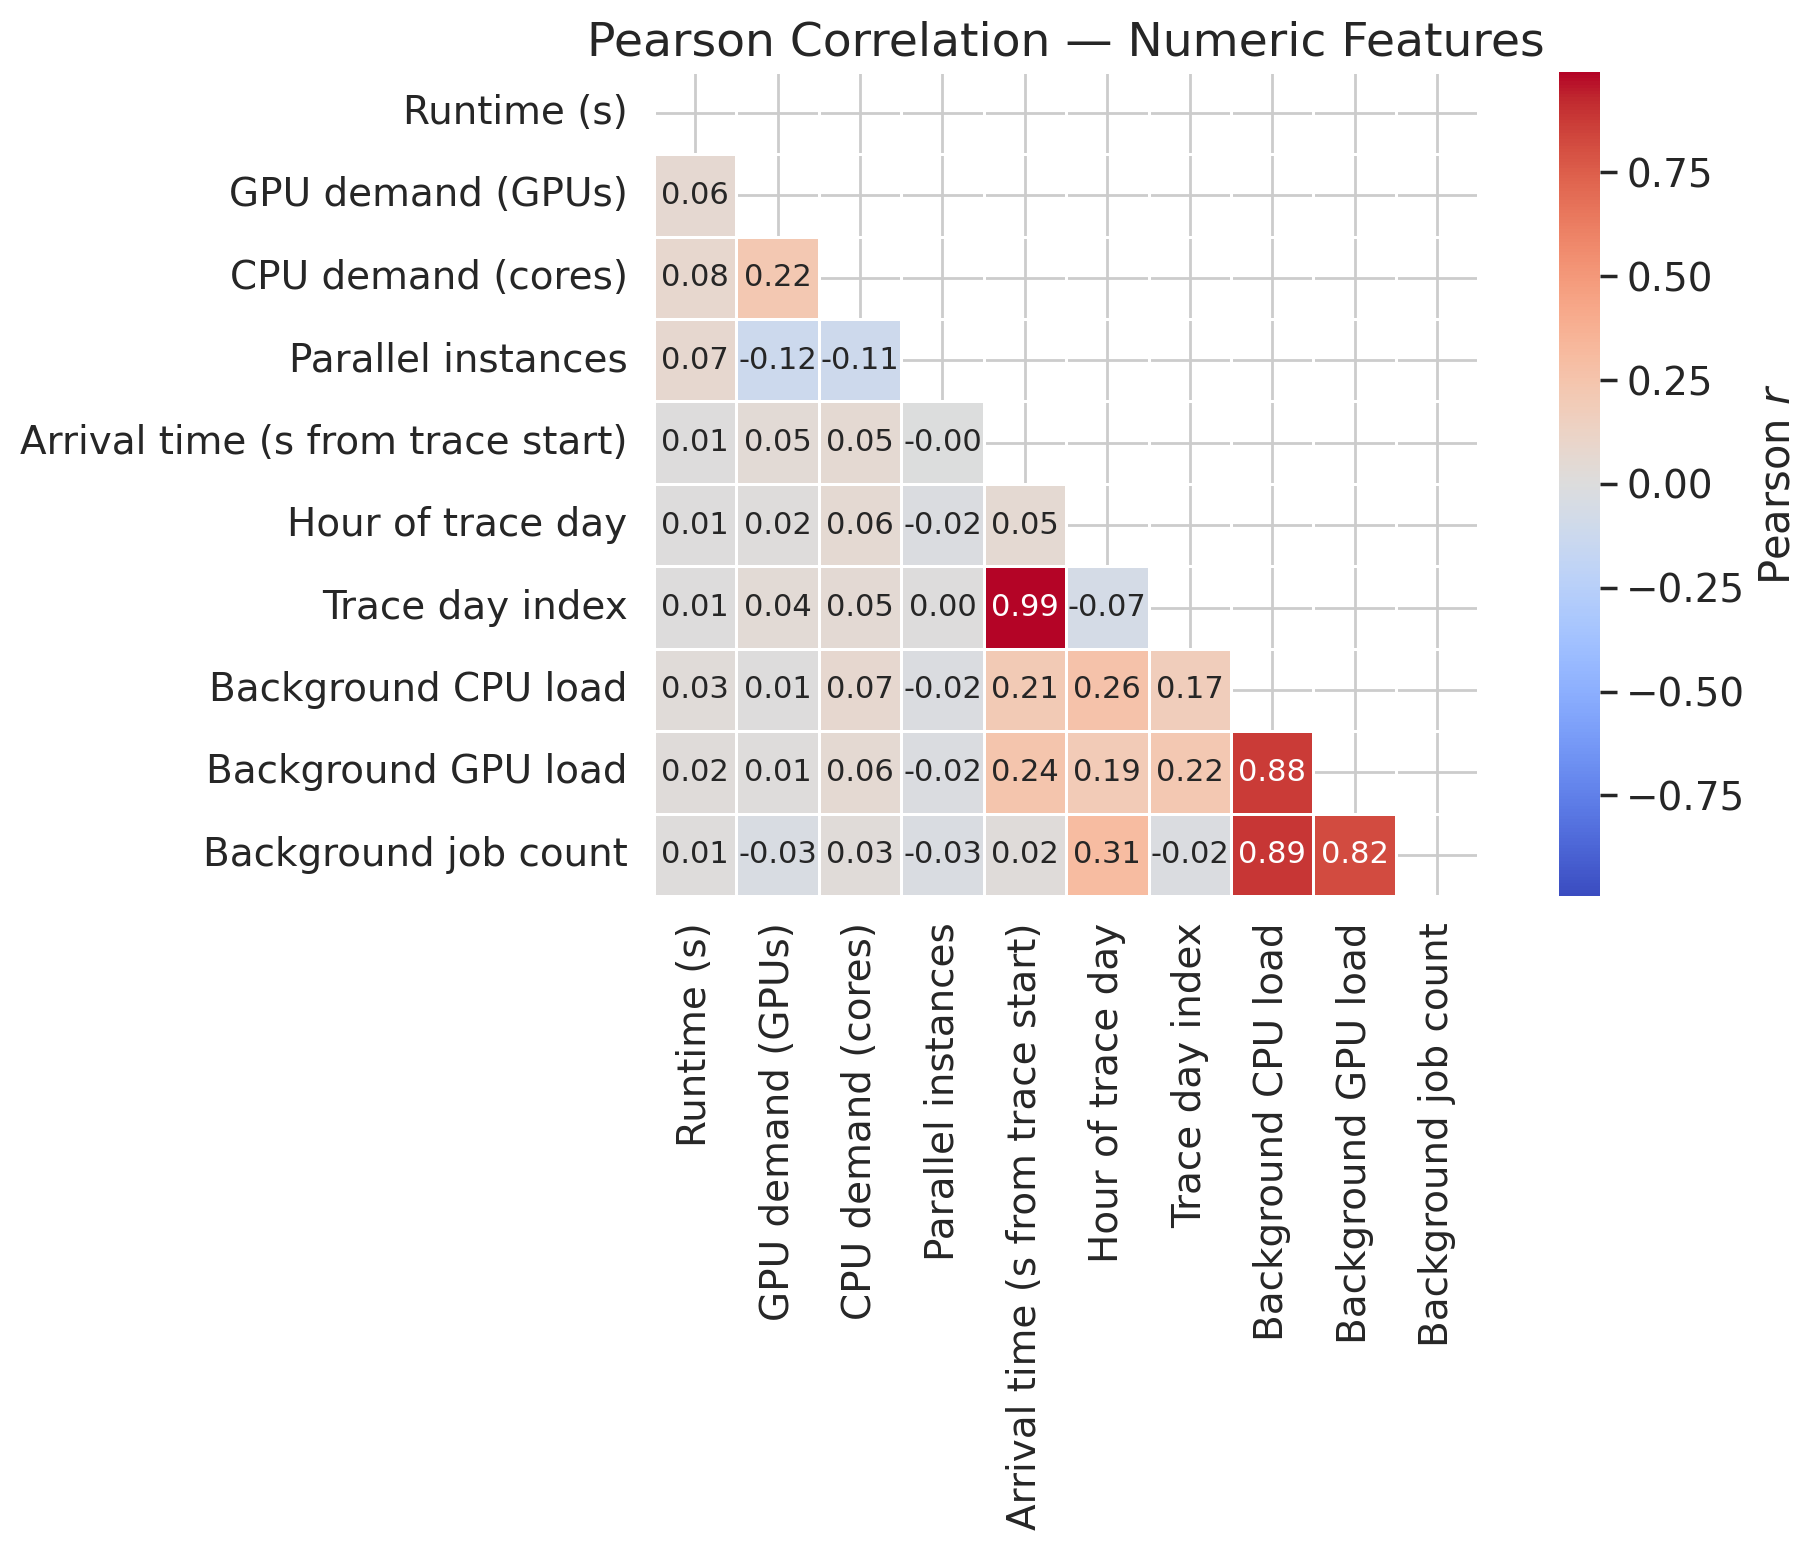


Correlation with job_runtime:
num_cpu             0.080097
num_inst            0.071895
gpu_demand          0.064362
cluster_load_cpu    0.027174
cluster_load_gpu    0.021684
active_job_count    0.013380
hour_of_day         0.007071
arrival_sec         0.006966
day_of_week         0.006073


In [11]:
# ── 10. Correlation matrix heatmap ────────────────────────────────────────────
numeric_features = [
    "job_runtime", "gpu_demand", "num_cpu", "num_inst",
    "arrival_sec", "hour_of_day", "day_of_week",
    "cluster_load_cpu", "cluster_load_gpu", "active_job_count",
]
numeric_features = [c for c in numeric_features if c in job_df.columns]

corr = job_df[numeric_features].corr()
# Raw column identifiers made poor tick labels ("day_of_week" is a trace-day
# index here, not a weekday). Renamed for the figure only.
_FEATURE_LABELS = {
    "job_runtime":      "Runtime (s)",
    "gpu_demand":       "GPU demand (GPUs)",
    "num_cpu":          "CPU demand (cores)",
    "num_inst":         "Parallel instances",
    "arrival_sec":      "Arrival time (s from trace start)",
    "hour_of_day":      "Hour of trace day",
    "day_of_week":      "Trace day index",
    "cluster_load_cpu": "Background CPU load",
    "cluster_load_gpu": "Background GPU load",
    "active_job_count": "Background job count",
}
# Display copy only: the printout below (and anything else downstream) still
# needs the raw column names.
corr_display = corr.rename(index=_FEATURE_LABELS, columns=_FEATURE_LABELS)

fig, ax = plt.subplots(figsize=(11, 8))
# The correlation matrix is symmetric, so masking the upper triangle keeps each
# coefficient on the figure once. k=0 masks the diagonal too: a row of 1.00s
# pins the colour ramp to +/-1 and flattens every real correlation.
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
_corr_max = float(np.nanmax(np.abs(corr.where(~mask))))
# The cells are ~0.9 in wide, so the 15 pt base size overruns them and values
# run together. The annotation size is set for the cell, not the figure.
sns.heatmap(corr_display, ax=ax, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            annot_kws={"size": 11},
            vmin=-_corr_max, vmax=_corr_max, linewidths=0.4, square=True,
            cbar_kws={"label": "Pearson $r$"})
ax.set_title("Pearson Correlation — Numeric Features")
plt.tight_layout()
plt.show()

print(f"\nCorrelation with job_runtime:")
print(corr["job_runtime"].drop("job_runtime").sort_values(ascending=False).to_string())

> **Figure 2 — Pearson Correlation Matrix (Numeric Features vs. Job Runtime):**
>
> The resulting heatmap definitively justifies the heavy-artillery artificial intelligence mandated by the thesis. While human intuition fundamentally expects that requesting more CPUs (`num_cpu`) or GPUs (`gpu_demand`) linearly dictates a longer execution duration (`job_runtime`), the actual Pearson correlation coefficients brutally betray this assumption, yielding the minuscule scores printed under the figure by `corr["job_runtime"]` — **0.08 and 0.06** respectively.
>
> While the engineered Sweep-line cluster utilization features correlate tightly with one another (0.82-0.89 across the three `cluster_load_cpu` / `cluster_load_gpu` / `active_job_count` pairs), absolutely no isolated variable retains a discernible linear bond with the target `job_runtime`; the strongest of them, `num_cpu`, stops at 0.08. (The largest off-diagonal value on the figure, 0.99, is `arrival_sec` against `day_of_week` — expected, since the day index is simply the arrival second coarsened to whole days, and one more reminder that it is a trace clock rather than a calendar.) This matrix constitutes the absolute mathematical proof as to why simplistic linear regressions collapse on the grid; securing highly accurate predictions strictly requires deploying advanced decision trees (XGBoost) and profound complex neural structures (CNN, LSTM).

In [12]:
# ── 11. Feature set definition ────────────────────────────────────────────────
numeric_cols = [
    "gpu_demand", "arrival_sec", "num_inst", "num_cpu",
    "hour_of_day", "day_of_week",
    "cluster_load_cpu", "cluster_load_gpu", "active_job_count",
]
numeric_cols = [c for c in numeric_cols if c in job_df.columns]

categorical_cols = []
if "user" in job_df.columns:
    categorical_cols.append("user")
if "gpu_type" in job_df.columns:
    categorical_cols.append("gpu_type")

print(f"Numeric  features ({len(numeric_cols)})    : {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}) : {categorical_cols}")

Numeric  features (9)    : ['gpu_demand', 'arrival_sec', 'num_inst', 'num_cpu', 'hour_of_day', 'day_of_week', 'cluster_load_cpu', 'cluster_load_gpu', 'active_job_count']
Categorical features (2) : ['user', 'gpu_type']


> **Feature Space Definition:** To perfectly optimize the predictive algorithms and robust pattern recognition capabilities, the most potent signals representing systemic bottlenecks, hardware demands, and characteristic chronological loops have been strictly isolated.
>  
> By systematically purging noisy raw text attributes prone to disrupting computational branching, the ultimate high-density feature matrix designated for deep learning and neural network integration is flawlessly established.

In [13]:
# ── 12. Train / Test split ────────────────────────────────────────────────────
print("[Step 9] Splitting into train / test sets...")
X_train, X_test, y_train, y_test = build_feature_matrix(
    job_df,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col="job_runtime",
    test_size=0.20,
    random_state=42,
)

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}  |  y_test : {y_test.shape}")
print(f"Target  — mean : {y_train.mean():.1f}s   median : {float(np.median(y_train)):.1f}s")

[Step 9] Splitting into train / test sets...
X_train : (65747, 11)  |  X_test : (16437, 11)
y_train : (65747,)  |  y_test : (16437,)
Target  — mean : 5021.3s   median : 568.0s


> **Temporal Leakage Shielding (Absolute Chronological Segregation):**
> Conventional randomized train/test splitting mechanisms heavily utilized in generic machine learning pipelines are absolutely forbidden within this thesis framework. Unintentionally exposing future operational states to historical training permutations induces a catastrophic architectural failure known as chronological data-leakage. 
> 
> To completely neutralize this threat, the massive 82,184-job feature matrix was **severed decisively along a rigid chronological timeline**, irrevocably sealing the primary consecutive 80% span as the training boundary (Train), and locking the deeply unobserved final 20% future horizon for evaluation (Test). This uncompromising segregation forms the unbreakable foundation assuring perfect real-world validity and preserving total metric integrity during the subsequent modeling cycles (Notebook 04).


## Summary

The fundamental Feature Engineering pipeline executed within this notebook fundamentally transcends basic manipulation, meticulously engineering a single unified structural matrix explicitly designed to drive both incoming **Machine Learning (XGBoost, LightGBM, Random Forest)** and **Deep Learning (CNN, LSTM)** architectures simultaneously:

| Engineered Feature | Impact on Algorithmic Networks |
|---|---|
| **Event-Driven Sweep-Line (Load)** | Translates unobservable, hidden ambient hardware bottlenecks surrounding simultaneously queued tasks into a direct algorithmic input, enabling dynamic decisioning for trees and neural networks. |
| **Chronological Diurnal Cycles** | Hands sequential networks (like LSTM) the relative within-day submission rhythm plus a trace-day counter (`day_of_week`, 0-7 over this trace, not a calendar weekday), strictly rejecting basic execution randomness. |
| **Native Categorical Transformation** | Maximizes the internal computational mechanics of Machine Learning engines (XGBoost/LightGBM), decisively averting the devastating "Curse of Dimensionality" spawned by legacy One-Hot arrays, profoundly optimizing memory footprint. |
| **Strict Temporal Segregation** | Decisively prohibits fatal chronological data-leakage from contaminating the Train/Test split axis, firmly anchoring the absolute real-world validity of both subsequent deep learning and machine learning validation metrics. |

These structural designs systematically prevent calculation engines from collapsing within unstructured noise. The resulting rigorously partitioned matrix (80% Train, 20% Test) acts directly as the uncompromising foundation for the hybrid AI-driven **global scheduling optimization** deployed in Notebook 04.
